In [50]:
import torch
import deepinv as dinv
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
import os
import time

PSNR = dinv.metric.PSNR()

sys.path.append(os.path.abspath(".."))

from multilevel.utils import WaveletPriorCustom
from block.block import BlockCoordinateDescent

seed = torch.manual_seed(0)  # Random seed for reproducibility

In [51]:
n_iter = 500
n_coarse_steps = 10
reg_weight = 0.1
data_fidelity = dinv.optim.L2()

def initialize_params(x_true, J):
    sigma = 0.01
    noise_model = dinv.physics.GaussianNoise(sigma=sigma)
    physics = dinv.physics.Inpainting(img_size=x_true.shape[1:], mask=0.8, noise_model=noise_model)

    prior = WaveletPriorCustom(wv='db8', level=J)

    Anorm2 = physics.compute_norm(x_true).item()
    stepsize = 0.05/Anorm2

    return physics, prior, stepsize

In [52]:
def run_BCD_FB(x0, y, x_true, physics, data_fidelity, J, stepsize, reg_weight, n_coarse_steps):
    only_cycles = True

    prior_l1 = dinv.optim.L1Prior()
    len_cycle = J+1
    n_cycles = 40
    #n_cycles = int(n_iter / (len_cycle * n_coarse_steps * (J + 1)))

    xk = x0.clone()
    bcd = BlockCoordinateDescent(x_true.shape, wv_type='db8', physics=physics, data_fidelity=data_fidelity, prior=prior_l1, max_levels=J, stepsize=stepsize)

    recon, loss, times, cycles, psnr = bcd.run(y=y, x0=xk, x_true=x_true, n_iter=n_cycles, n_iter_coarse=n_coarse_steps, reg_weight=reg_weight, update_mode='FB', metrics=True)

    cycles = [1] + cycles

    # To only keep the values at the end of each cycle
    if only_cycles == True:
        loss = [loss[index-1] for index in cycles]
        psnr = [psnr[index-1] for index in cycles]
        times = [times[index-1] for index in cycles]

    print(len(loss))
    return recon, loss, psnr, times, cycles

def run_FB(x0, y, x_true, physics, data_fidelity, J, stepsize, reg_weight, n_coarse_steps, prior):
    only_cycles = False

    loss, psnr, times = [data_fidelity.fn(x0, y, physics).item() + reg_weight * prior.fn(x0).item()], [PSNR(x0, x_true).item()], [0]
    n = x0.shape[-1] * x0.shape[-2]
    filter_size = 8  # for db8
    cost = [n**3 + n**2]
    start = time.process_time()

    stepsizeATy = stepsize * physics.A_adjoint(y)

    n_cycles = 40
    n_iter = n_cycles * n_coarse_steps * (J + 1)

    xk = x0.clone()
    with torch.no_grad():
        with tqdm(range(n_iter), desc="FB") as t:
            for k in t:
                cost.append(cost[-1] + n**2 + n*filter_size**2 + n)
                xk = xk - stepsize * (physics.A_adjoint(physics.A(xk))) + stepsizeATy
                xk = prior.prox(xk, gamma=stepsize * reg_weight)

                if only_cycles:
                    if k % (n_coarse_steps*(J+1)) == 0:
                        if x_true is not None:
                            current_psnr = PSNR(xk, x_true).item()
                            psnr.append(current_psnr)
                        current_loss =  data_fidelity.fn(xk, y, physics).item() + reg_weight * prior.fn(xk).item()
                        t.set_postfix(loss=f"{current_loss:.4f}")
                        loss.append(current_loss)
                        times.append(time.process_time() - start)
                else:
                    current_loss_val = data_fidelity.fn(xk, y, physics).item() + reg_weight * prior.fn(xk).item()
                    loss.extend([current_loss_val] * 1)

                    if x_true is not None:
                        current_psnr_val = PSNR(xk, x_true).item()
                        psnr.extend([current_psnr_val] * 1)

                    current_time_val = time.process_time() - start
                    times.extend([current_time_val] * 1)

    recon = xk.clone()
    cycles = None
    return recon, loss, psnr, times, cycles, cost

In [53]:
def run_BCD_cyclic(x0, y, x_true, physics, data_fidelity, J, stepsize, reg_weight, n_coarse_steps):
    only_cycles = True
    prior_l1 = dinv.optim.L1Prior()
    len_cycle = J+1
    n_cycles=40
    #n_cycles = int(n_iter / (len_cycle * n_coarse_steps * (J + 1)))

    n = x0.shape[-1] * x0.shape[-2]

    xk = x0.clone()
    bcd = BlockCoordinateDescent(x_true.shape, wv_type='db8', physics=physics, data_fidelity=data_fidelity, prior=prior_l1, max_levels=J, stepsize=stepsize)

    recon, loss, times, cycles, psnr = bcd.run(y, xk, x_true=x_true, n_iter=n_cycles, n_iter_coarse=n_coarse_steps, reg_weight=reg_weight, update_mode='cyclic', metrics=True)

    cost = [n**3 + n**2 + ((2/(3*4**J) +1/3))*n**2 + (2/(3*4**J) +1/3)*n**3 + (1/4**(2*J) + (1-1/4**J)**2/9 + (2*(1-1/4**J))/(3*4**J))*n**3]
    cost += [cost[0] + k*((1/4**(2*J) + (1-1/4**J)**2/9 + (2*(1-1/4**J)/(3*4**J)))*n**2 + (2/(3*4**J) + 1/3)*n ) for k in range(1, len(cycles)+1)]

    cycles = [1] + cycles

    print(len(cost))

    # To only keep the values at the end of each cycle
    if only_cycles == True:
        loss = [loss[index-1] for index in cycles]
        psnr = [psnr[index-1] for index in cycles]
        times = [times[index-1] for index in cycles]

    return recon, loss, psnr, times, cycles, cost

Power iteration converged at iteration 2, value=1.00


BCD cyclic: 100%|██████████| 40/40 [00:16<00:00,  2.45it/s, loss=1016.05]

41


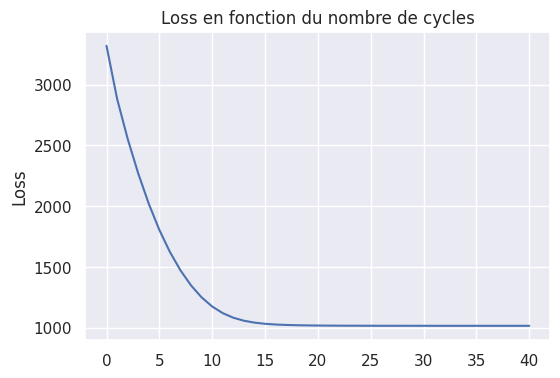

In [54]:
x = dinv.utils.load_example('butterfly.png')
physics, prior, stepsize = initialize_params(x, J=3)
y = physics(x)
x0 = y.clone()

recon, loss, psnr, times, cycles, cost = run_BCD_cyclic(
    x0, y, x, physics, data_fidelity, 3, stepsize, reg_weight, n_coarse_steps
)

plt.figure(figsize=(6,4))
plt.plot(loss)
plt.ylabel("Loss")
plt.title("Loss en fonction du nombre de cycles")
plt.grid(True)

Image dimension: 128x128, J: 3
Power iteration converged at iteration 2, value=1.00


BCD cyclic:   0%|          | 0/40 [00:00<?, ?it/s, loss=1199.14]

BCD cyclic: 100%|██████████| 40/40 [00:03<00:00, 12.82it/s, loss=1197.58]
/home/edgar/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


41
Image dimension: 128x128, J: 4
Power iteration converged at iteration 2, value=1.00


BCD cyclic: 100%|██████████| 40/40 [00:04<00:00,  9.90it/s, loss=1212.18]
/home/edgar/.local/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


...

41
Image dimension: 1024x1024, J: 4
Power iteration converged at iteration 2, value=1.00


BCD cyclic: 100%|██████████| 40/40 [01:35<00:00,  2.39s/it, loss=74799.97]


41
Image dimension: 1024x1024, J: 5
Power iteration converged at iteration 2, value=1.00


BCD cyclic: 100%|██████████| 40/40 [01:55<00:00,  2.88s/it, loss=75091.80]


41


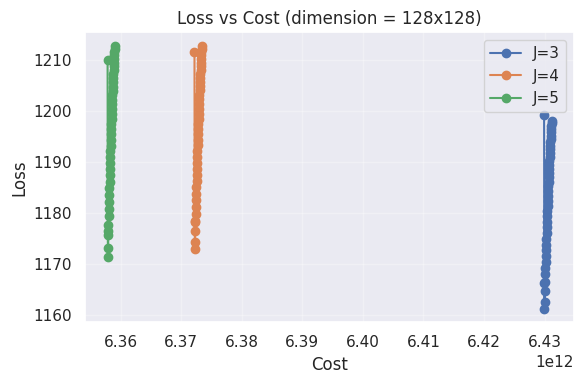

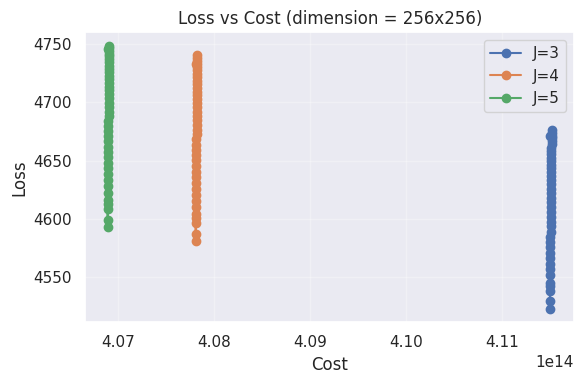

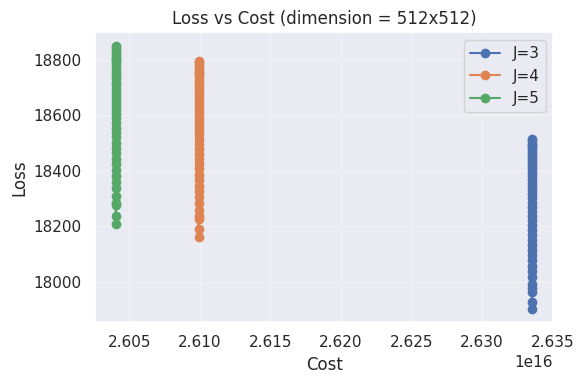

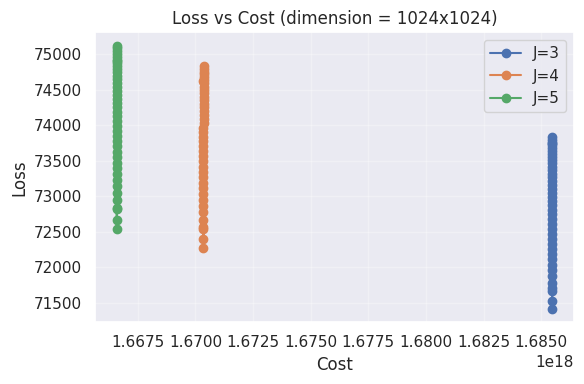

In [55]:
dims = [128, 256, 512, 1024]
Js = [3, 4, 5]

results = {}

for dim in dims:
    results[dim] = {}
    for J in Js:
        print(f"Image dimension: {dim}x{dim}, J: {J}")
        x = torch.randn(1, 1, dim, dim)
        physics, prior, stepsize = initialize_params(x, J)
        y = physics(x)
        x0 = y.clone()

        recon, loss, psnr, times, cycles, cost = run_BCD_cyclic(
            x0, y, x, physics, data_fidelity, J, stepsize, reg_weight, n_coarse_steps
        )

        # Stocke les courbes pour chaque J
        results[dim][J] = {"loss": loss, "cost": cost}

# === Affichage ===
for dim in dims:
    plt.figure(figsize=(6, 4))
    for J in Js:
        data = results[dim][J]
        plt.plot(data["cost"], data["loss"], label=f"J={J}", marker="o")
    plt.title(f"Loss vs Cost (dimension = {dim}x{dim})")
    plt.xlabel("Cost")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

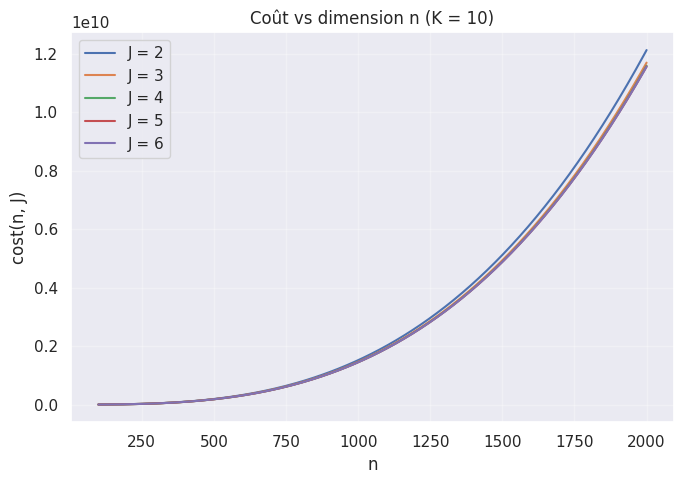

In [59]:
import numpy as np

def cost_bcd(n, J, K):
    return (
        n**3
        + n**2
        + ((2/(3*4**J) + 1/3)) * n**2
        + (2/(3*4**J) + 1/3) * n**3
        + (1/4**(2*J) + (1 - 1/4**J)**2 / 9 + (2 * (1 - 1/4**J)) / (3 * 4**J)) * n**3
        + K * (
            (1/4**(2*J)
             + (1 - 1/4**J)**2 / 9
             + (2 * (1 - 1/4**J)) / (3 * 4**J)) * n**2
            + (2 / (3 * 4**J) + 1/3) * n
        )
    )

# Paramètres
K = 10                # K fixé
Js = [2, 3, 4, 5, 6]  # valeurs de J à comparer
n = np.linspace(100, 2000, 200)  # plage de n

# Plot
plt.figure(figsize=(7, 5))
for J in Js:
    cost = cost_bcd(n, J, K)
    plt.plot(n, cost, label=f"J = {J}")

plt.title(f"Coût vs dimension n (K = {K})")
plt.xlabel("n")
plt.ylabel("cost(n, J)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()